# Task 3: Extended Apriori with Multiple Minimum Support (MIS)

### Requirements
1.	Extended Apriori with MIS (Multiple Minimum Item Support)
Modify your frequent itemset generation functions to accept multiple minimum support thresholds as input.
2.	Pruning:
Modify your pruning function to prune itemsets that do not meet any of the minimum support thresholds. Also print pruned and qualified itemsets for each minimum support threshold. 
Comment on how this impacts the search space and computational efficiency.
3.	Apply MIS algorithm on given dataset. Find all frequent itemsets using minimum Support and Confidence.  
    - Show candidates & qualified items at each level. 
    - Identify Strong and Weak rules with confidence threshold of 80%.
    - Itemset/Combination of itemset removed due to head itemset problem? 
    - Evaluate the adaptability of the algorithm for real-life datasets with skewed item frequency distributions.
4.	Analysis and Reflection:
Reflect on the strengths and limitations of using MIS-based Apriori:
    - When is MIS beneficial? What are the trade-offs in performance?
    - How does it compare to traditional single-threshold Apriori?
    - What challenges arise when selecting appropriate support values?

*Summarise the strong vs weak association rules in a table and discuss how the algorithm adapts to varying support thresholds, and its strengths/limitations in data mining tasks.*

---------------------



In [ ]:
# Import required libraries
import pandas as pd
import itertools
import time
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load the preprocessed and prepare dataset

# Load the dataset
filepath = '../../data/processed/preprocessed_data.csv'
df = pd.read_csv(filepath)

# Convert to transaction format
transactions = []
for invoice, group in df.groupby('Invoice'):
    items = set(group['Description'].dropna().unique())
    if items:
        transactions.append(items)

total_transactions = len(transactions)

print(f"Total Transactions: {total_transactions}")
print(f"Sample Transaction: {list(transactions[0])[:5]}..")

Total Transactions: 1802
Sample Transaction: ['RED WOOLLY HOTTIE WHITE HEART.', 'GLASS STAR FROSTED T-LIGHT HOLDER', 'SET 7 BABUSHKA NESTING BOXES', 'CREAM CUPID HEARTS COAT HANGER', 'KNITTED UNION FLAG HOT WATER BOTTLE']..


In [26]:
# 3.1. Define MIS Threshold for 5 Products

# Analyze item frequencies 
item_counts= defaultdict(int)
for transaction in transactions:
    for item in transaction:
        item_counts[item] += 1

# Sort item by frequency
sorted_items = sorted(item_counts.items(), key=lambda x: x[1], reverse=True)

print("=" * 80)
print("IDENTIFY AND DEFINE MIS THRESHOLDS")
print("=" * 80)
print("Items by Frequency: ")
print("=" * 80)
print(f"{'Rank':<6} {'Item':<55} {'Count':<10} {'Support %':<10}")
print("-" * 80)
for i, (item, count) in enumerate(sorted_items, 1):
    support_pct = (count / total_transactions) * 100
    print(f"{i:<6} {item[:55]:<55} {count:<10} {support_pct:<10.2f}")

IDENTIFY AND DEFINE MIS THRESHOLDS
Items by Frequency: 
Rank   Item                                                    Count      Support % 
--------------------------------------------------------------------------------
1      WHITE HANGING HEART T-LIGHT HOLDER                      275        15.26     
2      REGENCY CAKESTAND 3 TIER                                205        11.38     
3      HAND WARMER BABUSHKA DESIGN                             184        10.21     
4      SCOTTIE DOG HOT WATER BOTTLE                            176        9.77      
5      HEART OF WICKER SMALL                                   171        9.49      
6      PAPER CHAIN KIT 50'S CHRISTMAS                          168        9.32      
7      CHOCOLATE HOT WATER BOTTLE                              161        8.93      
8      JAM MAKING SET PRINTED                                  160        8.88      
9      JUMBO BAG RED RETROSPOT                                 148        8.21      
10     HEART 

In [28]:
# Define MIS threshold for 5 selected products
# Selected based on high to low frequency frequency

# Defined as high=221-275, high-medium=166-220, medium=111-165, medium-low=56-110, low=<55
MIS_THRESHOLDS = {
    # Highest frequency item - higher MIS threshold
    'WHITE HANGING HEART T-LIGHT HOLDER': 100,      # count=275, top 1
    # Medium=high frequency item
    'REGENCY CAKESTAND 3 TIER': 80,                 # count=205, top 2
    # Medium frequency item
    'CHOCOLATE HOT WATER BOTTLE': 70,               # count=161, top 7
    # Medium-low frequency item
    'RED HANGING HEART T-LIGHT HOLDER': 60,        # count=110, top 29
    # Low frequency item
    'STRAWBERRY CHARLOTTE BAG': 50                  # count=55, tio 175               
}

# Standard parameters
MIN_SUPPORT = 0.02      # 2% default
MIN_CONFIDENCE = 0.80   # 80% confidence
MAX_K = 5               # Maximum k

print("=" * 80)
print("MIS THRESHOLDS FOR 5 SELECTED PRODUCTS")
print("=" * 80)
print(f"{'Product':<55} {'MIS Count':<15} {'MIS %':<10}")
print("-" * 80)
for item, mis in MIS_THRESHOLDS.items():
    actual_count = item_counts.get(item, 0)
    mis_pct = (mis / total_transactions) * 100
    status = "PASSED" if actual_count >= mis else "FAILED"
    print(f"{item[:55]:<55} {mis:<15} {mis_pct:<10.2f} {status}")

print("\n" + "=" * 80)
print("Rationale for MIS Selection: ")
print("  - Higher MIS for frequent items (reduces search space)")
print("  - Lower MIS for rare items (captures interesting rare patterns)")
print("  - Allows discovery of rules involving both frequent and rare items")


MIS THRESHOLDS FOR 5 SELECTED PRODUCTS
Product                                                 MIS Count       MIS %     
--------------------------------------------------------------------------------
WHITE HANGING HEART T-LIGHT HOLDER                      100             5.55       PASSED
REGENCY CAKESTAND 3 TIER                                80              4.44       PASSED
CHOCOLATE HOT WATER BOTTLE                              70              3.88       PASSED
RED HANGING HEART T-LIGHT HOLDER                        60              3.33       PASSED
STRAWBERRY CHARLOTTE BAG                                50              2.77       PASSED

Rationale for MIS Selection: 
  - Higher MIS for frequent items (reduces search space)
  - Lower MIS for rare items (captures interesting rare patterns)
  - Allows discovery of rules involving both frequent and rare items


In [29]:
# Implement full MIS-Extended Apriori Implementation via Class

class MISAprioriAlgo:
    """
    Apriori algo with MIS extension

    Implementation allows different items to have different minimum 
    support thresholds, enabling discovery of rare but interesting patterns.
    """

    def __init__(self, min_support=MIN_SUPPORT, min_confidence=MIN_CONFIDENCE, max_k=MAX_K):
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.max_k = max_k
        self.frequent_itemsets = {}
        self.execution_time = 0
        self.transactions = []
        self.total_transactions = 0
        self.level_stats = {}
        self.pruned_by_head_item = []       # Track head itemset problem
        # Track computing resource consumption
        self.consumption_stats = {
            'subset_checks': {},    # Count of (candidates * transactions)
            'join_ops': {},         # Number of potential combinations attempted
            'memory_itemsets': {}   # Peak itemsets stored per level
        }

    def load_data(self, filepath):
        # Load dataset and create transactions
        df = pd.read_csv(filepath)
        self.transactions = []
        for invoice, group in df.groupby('Invoice'):
            items = set(group['Description'].dropna().unique())
            if items:
                self.transactions.append(items)
        self.total_transactions = len(self.transactions)
        return self

    def get_default_support_count(self):
        # Get default support count for items without MIS
        return int(self.min_support * self.total_transactions)
    
    def get_item_mis(self, item, mis_thresholds):
        # Get MIS threshold for a specific item
        return mis_thresholds.get(item, self.get_default_support_count())

    def get_itemset_mis(self, itemset, mis_thresholds):
        # Get minimum MIS for an itemset (For k-itemsets, ues the minim MIS among all items)
        return min(self.get_item_mis(item, mis_thresholds) for item in itemset)
    
    def generate_frequent_1_itemsets(self, mis_thresholds, verbose=True):
        """
        Generate frequent 1-itemsets w/ individual MIS thresholds

        Parameters:
        mis_thresholds: dict - mappung items to their MIS thresholds
        verbose: bool - print detailed output

        Returns:
        frequent_1_itemsets: dict - frequent 1-itemsets
        pruned_itemsets: dict - pruned itemsets
        """
        item_counts = defaultdict(int)

        for transaction in self.transactions:
            for item in transaction:
                item_counts[item] += 1

        # Sort by minimum support - ascending order
        sorted_items_by_mis = sorted(
            item_counts.keys(), 
            key=lambda x: self.get_item_mis(x, mis_thresholds)
        )

        frequent_1_itemsets = {}
        pruned_itemsets = {}

        for item in sorted_items_by_mis:
            count = item_counts[item]
            mis = self.get_item_mis(item, mis_thresholds)
            itemset = frozenset([item])

            if count >= mis:
                frequent_1_itemsets[itemset] = count
            else:
                pruned_itemsets[itemset] = count

        # Store sorted order for k = 2 logic
        self.sorted_order = sorted_items_by_mis

        # Level 1 consumption: 
        self.consumption_stats['memory_itemsets'][1] = len(item_counts)
        self.consumption_stats['subset_checks'][1] = len(item_counts) * self.total_transactions

        if verbose:
            print("\n" + "=" * 80)
            print("FREQUENT 1-ITEMSETS: Level 1 (with MIS): ")
            print("=" * 80)
            print(f"\nTotal unique items (candidates): {len(item_counts)}")
            print(f"  - Qualified itemsets: {len(frequent_1_itemsets)}")
            print(f"  - Pruned itemsets: {len(pruned_itemsets)}")

            # Show items with custom MIS thresholds
            print("-" * 80)
            print(f"\nItems with Custom MIS Thresholds: ")
            print("-" * 80)
            for item, mis in mis_thresholds.items():
                count = item_counts.get(item, 0)
                status = "QUALIFIED" if count >= mis else "PRUNED"
                support_pct = (count / self.total_transactions) * 100
                mis_pct = (mis / self.total_transactions) * 100
                print(f"  {item[:45]:<45} | MIS: {mis:>3} {mis_pct:>4.1f}% | Support: {support_pct:>4.1f}% |Count: {count:>4} | {status}" )
            
        return frequent_1_itemsets, pruned_itemsets
    
    def generate_frequent_k_itemsets(self, frequent_k_minus_1, k, mis_thresholds, verbose=True):
        """
        Generate frequent k-itemsets with MIS-based pruning

        Parameters:
        frequent_k_minus_1: dict - frequent k-1-itemsets
        k - int: current level
        mis_thresholds: dict - MIS thresholds
        verbose: bool - print detaoled output

        Returns:
        frequent_k_itemsets: dict - frequent k-itemsets
        pruned_itemsets: dict - pruned candidates
        head_itemset_removed: list - itemsets removed due to head itemset problem
        """

        if verbose:
            print("\n" + "=" * 80)
            print(f"Frequent {k}-Itemsets: Level {k} (with MIS)")
            print("=" * 80)
        
        # JOIN - generate candidates
        candidates = set()
        frequent_list = [] 
        join_attempts = 0

        for f_set in frequent_k_minus_1.keys():
            sorted_f = sorted(list(f_set), key=lambda x: self.sorted_order.index(x)) 
            frequent_list.append(sorted_f)


        for i in range(len(frequent_list)):
            for j in range(i + 1, len(frequent_list)):
                join_attempts += 1
                itemset1 = frequent_list[i]
                itemset2 = frequent_list[j]
    
                # Join condition: first k-2 items must match
                if itemset1[:k-2] == itemset2[:k-2]:
                    # Create candidate and maintain MIS order
                    candidate = frozenset(itemset1) | frozenset(itemset2)
                    if len(candidate) == k:
                        candidates.add(frozenset(candidate))

        candidates_after_join = len(candidates)

        # Record Join Cost & Memory Peak
        self.consumption_stats['join_ops'][k] = join_attempts
        self.consumption_stats['memory_itemsets'][k] = len(candidates)

        if verbose:
            print(f"JOIN STEP")
            print(f"   Candidates generated after join: {candidates_after_join}")

        # PRUNE - MIS-Specific Pruning (Structural Pruning)
        pruned_by_subset = {}
        candidates_to_remove = []
        head_itemset_removed = []

        for candidate in list(candidates):
            c_list = sorted(list(candidate), key=lambda x: self.sorted_order.index(x))
            head_item = c_list[0]
            subsets = [frozenset(x) for x in itertools.combinations(c_list, k-1)]

            for subset in subsets:
                # MIS RULE: Only prune is subset is missing && subset contains the item with the lowest MIS
                if subset not in frequent_k_minus_1:
                    if head_item in subset:
                        pruned_by_subset[candidate] = "Missing subset contains head item"
                        candidates_to_remove.append(candidate)
                        break
        
        for c in candidates_to_remove:
            candidates.discard(c)
        
        candidates_after_prune = len(candidates)

        # Record number of actual checks performed on the database
        total_checks = len(candidates) * self.total_transactions
        self.consumption_stats['subset_checks'][k] = total_checks


        if verbose:
            print(f"\nPRUNE Step: ")
            print(f"   Candidates pruned by head-item subset check: {len(pruned_by_subset)}")
            print(f"   Candidates remaining: {candidates_after_prune}")

        # Count Support for remaining candidates
        candidate_counts = {c: 0 for c in candidates}

        for transaction in self.transactions:
            for candidate in candidates:
                if candidate.issubset(transaction):
                    candidate_counts[candidate] += 1
        
        # Filter by MIS (Support Pruning) - using min MIS among items in itemset
        frequent_k_itemsets = {}
        pruned_by_support = {}

        for candidate, count in candidate_counts.items():
            min_mis = self.get_itemset_mis(candidate, mis_thresholds)

            if count >= min_mis:
                frequent_k_itemsets[candidate] = count
            else: 
                pruned_by_support[candidate] = {'count': count, 'required_mis': min_mis}

        if verbose:
            print(f"\nSUPPORT Counting with MIS: ")
            print(f"    Candidates meeting MIS Threshold: {len(frequent_k_itemsets)}")
            print(f"    Candidates pruned by MIS: {len(pruned_by_support)}")

            if frequent_k_itemsets:
                print(f"\nQualified {k}-Itemsets: ")
                sorted_frequent = sorted(frequent_k_itemsets.items(), key=lambda x: x[1], reverse=True)
                for itemset, count in sorted_frequent[:5]:
                    support_pct = (count / self.total_transactions) * 100
                    items_str = ', '.join(list(itemset))[:50]
                    print(f"    {{{items_str}}} | Count: {count} | Support: {support_pct:.2f}%")
            if pruned_by_support:
                print(f"\nSample of Pruned Itemsets (Failed Support):")
                for itemset, info in list(pruned_by_support.items())[:3]: # Shows first 3
                    print(f"  {list(itemset)} | Count: {info['count']} | Support: {info['required_mis']}")

        # Final stats recording
        self.level_stats[k] = {
            'candidates': self.consumption_stats['memory_itemsets'][k], 
            'qualified': len(frequent_k_itemsets), 
            'pruned': self.consumption_stats['memory_itemsets'][k] - len(frequent_k_itemsets)
        }
            
        all_pruned = {**{k: 0 for k in pruned_by_subset.keys()},
                        **{k: v['count'] for k, v in pruned_by_support.items()}}
        
        return frequent_k_itemsets, all_pruned, head_itemset_removed

    def print_consumption_report(self):
        print("\n" + "=" * 80)
        print("COMPUTATIONAL CONSUMPTION SUMMARY (MIS-EXTENDED)")
        print("=" * 80)
        for k in sorted(self.consumption_stats['subset_checks'].keys()):
            checks = self.consumption_stats['subset_checks'][k]
            joins = self.consumption_stats['join_ops'].get(k, 0)
            mem = self.consumption_stats['memory_itemsets'][k]
            print(f"Level {k}:")
            print(f"  - Join Cost (Comparisons): {joins:,}")
            print(f"  - Database Scan Cost (Subset Checks): {checks:,}")
            print(f"  - Memory Footprint (Candidates): {mem:,}")
    
    def run(self, mis_thresholds, verbose=True):
        # Execute MIS-extended Apriori Algorithm

        start_time = time.time()

        if verbose: 
            print("\n" + "=" * 80)
            print("MIS-EXTENDED APRIORI ALGORITHM")
            print("=" * 80)
            print(f"\nParameters: ")
            print(f"  - Total Transaction: {self.total_transactions}")
            print(f"  - Default Support: {self.min_support * 100}%")
            print(f"  - Maximum k: {self.max_k}")
            print(f"  - Number of ites with Custom MIST: {len(mis_thresholds)}")

        self.frequent_itemsets = {}
        self.level_stats = {}
        self.pruned_by_head_item = []

        # Level 1: Generate frequent 1-itemsets
        frequent_1, pruned_1 = self.generate_frequent_1_itemsets(mis_thresholds, verbose=verbose)
        self.frequent_itemsets.update(frequent_1)
        self.level_stats[1] = {
            'candidates': len(frequent_1) + len(pruned_1),
            'qualified': len(frequent_1),
            'pruned': len(pruned_1)
        }

        current_level = frequent_1

        # Levels 2 to max_k: Generate frequent k-itemsets
        for k in range(2, self.max_k + 1):
            if not current_level:
                break

            frequent_k, pruned_k, head_removed = self.generate_frequent_k_itemsets(
                current_level, k, mis_thresholds, verbose=verbose
            )

            self.pruned_by_head_item.extend(head_removed)
            self.level_stats[k] = {
                'candidates': len(frequent_k) + len(pruned_k),
                'qualified': len(frequent_k),
                'pruned': len(pruned_k)
            }

            if frequent_k:
                self.frequent_itemsets.update(frequent_k)
                current_level = frequent_k
            else:
                current_level = {}
        
        self.execution_time = time.time() - start_time

        if verbose:
            print("\n" + "=" * 80)
            print("Execution Summary: ")
            print("=" * 80)
            print(f"\nExecution Time: {self.execution_time:.4f} secoonds")
            print(f"Total Frequent Itemsets: {len(self.frequent_itemsets)}")

            print(f"\nLevel-wise Statistics")
            for level, stats in self.level_stats.items():
                print(f"  Level {level}: {stats['qualified']} qualified, {stats['pruned']} pruned")
        
        return self
    
    def generate_rules(self):
        # Generate association rules from frequent itemsets
        
        strong_rules = []
        weak_rules = []

        for itemset, support_count in self.frequent_itemsets.items():
            if len(itemset) < 2:
                continue

            for i in range(1, len(itemset)):
                for antecedent_items in itertools.combinations(itemset, i):
                    antecedent = frozenset(antecedent_items)
                    consequent = itemset - antecedent

                    antecedent_support = self.frequent_itemsets.get(antecedent, 0)

                    if antecedent_support > 0:
                        confidence = support_count / antecedent_support

                        consequent_support = self.frequent_itemsets.get(consequent, 0)
                        expected_confidence = consequent_support / self.total_transactions
                        lift = confidence / expected_confidence if expected_confidence > 0 else 0

                        rule = {
                            'antecedent': antecedent,
                            'consequent': consequent,
                            'support_count': support_count,
                            'support': support_count / self.total_transactions,
                            'confidence': confidence,
                            'lift': lift
                        }

                        if confidence >= self.min_confidence:
                            strong_rules.append(rule)
                        else:
                            weak_rules.append(rule)
        
        strong_rules.sort(key=lambda x: x['confidence'], reverse=True)
        weak_rules.sort(key=lambda x: x['confidence'], reverse=True)

        return strong_rules, weak_rules
    
print("MISAprioriAlgo class defined successfully!")


MISAprioriAlgo class defined successfully!


In [30]:
# Initialize and run MIS-Extended Apriori
mis_apriori = MISAprioriAlgo(min_support=MIN_SUPPORT, min_confidence=MIN_CONFIDENCE, max_k=MAX_K)
mis_apriori.load_data(filepath)
mis_apriori.run(mis_thresholds=MIS_THRESHOLDS, verbose=True)
mis_apriori.print_consumption_report()


MIS-EXTENDED APRIORI ALGORITHM

Parameters: 
  - Total Transaction: 1802
  - Default Support: 2.0%
  - Maximum k: 5
  - Number of ites with Custom MIST: 5

FREQUENT 1-ITEMSETS: Level 1 (with MIS): 

Total unique items (candidates): 2788
  - Qualified itemsets: 363
  - Pruned itemsets: 2425
--------------------------------------------------------------------------------

Items with Custom MIS Thresholds: 
--------------------------------------------------------------------------------
  WHITE HANGING HEART T-LIGHT HOLDER            | MIS: 100  5.5% | Support: 15.3% |Count:  275 | QUALIFIED
  REGENCY CAKESTAND 3 TIER                      | MIS:  80  4.4% | Support: 11.4% |Count:  205 | QUALIFIED
  CHOCOLATE HOT WATER BOTTLE                    | MIS:  70  3.9% | Support:  8.9% |Count:  161 | QUALIFIED
  RED HANGING HEART T-LIGHT HOLDER              | MIS:  60  3.3% | Support:  6.1% |Count:  110 | QUALIFIED
  STRAWBERRY CHARLOTTE BAG                      | MIS:  50  2.8% | Support:  3.1% 


MIS-EXTENDED LEVEL-WISE ANALYSIS: 
 Level (k)  Candidates  Qualified  Pruned Pruning Rate
         1        2788        363    2425        87.0%
         2       65703        294   65409        99.6%
         3        1020         32     988        96.9%
         4          14          0      14       100.0%

Note: Pruning Rate = Pruned / Candidates * 100


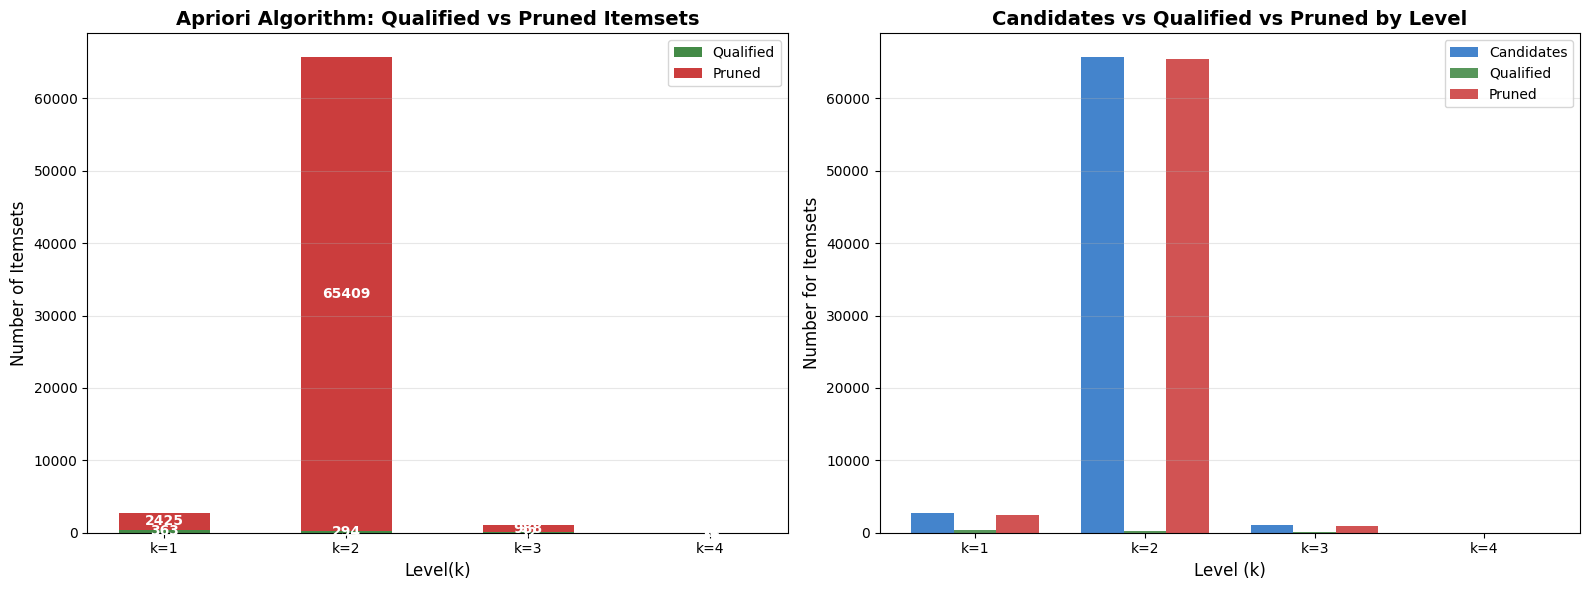

In [31]:
# Show Candidates and Qualified Items at Each Level
level_data = {
    'Level (k)': [],
    'Candidates': [],
    'Qualified': [],
    'Pruned': [],
    'Pruning Rate': []
}

for level, stats in mis_apriori.level_stats.items():
    level_data['Level (k)'].append(level)
    level_data['Candidates'].append(stats['candidates'])
    level_data['Qualified'].append(stats['qualified'])
    level_data['Pruned'].append(stats['pruned'])
    pruning_rate = (stats['pruned'] / stats['candidates'] * 100) if stats['candidates'] > 0 else 0
    level_data['Pruning Rate'].append(f"{pruning_rate:.1f}%")

level_df = pd.DataFrame(level_data)

print("\n" + "=" * 80)
print("MIS-EXTENDED LEVEL-WISE ANALYSIS: ")
print("=" * 80)
print(level_df.to_string(index=False))

print("\nNote: Pruning Rate = Pruned / Candidates * 100")

# Visualization: MIS - Candidate vs Qualified vs. Pruned at each level

# Create visualization of the Apriori process
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


levels = list(mis_apriori.level_stats.keys())
qualified = [mis_apriori.level_stats[l]['qualified'] for l in levels]
pruned = [mis_apriori.level_stats[l]['pruned'] for l in levels]
candidates = [mis_apriori.level_stats[l]['candidates'] for l in levels]

x = np.arange(len(levels))
width = 0.25

# Plot 1: stacked bar chart
axes[0].bar(x, qualified, width*2, label='Qualified', color='#2E7D32', alpha=0.9)
axes[0].bar(x, pruned, width*2, bottom=qualified, label='Pruned', color='#C62828', alpha=0.9)
axes[0].set_xlabel('Level(k)', fontsize=12)
axes[0].set_ylabel('Number of Itemsets', fontsize=12)
axes[0].set_title('Apriori Algorithm: Qualified vs Pruned Itemsets', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'k={l}' for l in levels])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, (q, p) in enumerate(zip(qualified, pruned)):
    axes[0].text(i, q/2, str(q), ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    if p > 0:
        axes[0].text(i, q + p/2, str(p), ha='center', va='center', fontsize=10, fontweight='bold', color='white')

#Plot 2: Grouped bar chart
axes[1].bar(x - width, candidates, width, label='Candidates', color='#1565C0', alpha=0.8)
axes[1].bar(x, qualified, width, label='Qualified', color='#2E7D32', alpha=0.8)
axes[1].bar(x + width, pruned, width, label='Pruned', color='#C62828', alpha=0.8)
axes[1].set_xlabel('Level (k)', fontsize=12)
axes[1].set_ylabel('Number for Itemsets', fontsize=12)
axes[1].set_title('Candidates vs Qualified vs Pruned by Level', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'k={l}' for l in levels])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../visuals/mis_apriori_level_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


MIS-EXTENDED: ASSOCIATION RULES: 

Confidence Threshold: 80.0%

Total Rules Generated: 777
  Strong Rules (confidence >= 80.0%): 31
  Weak Rules (confidence < 80.0%): 746

Top 10 Strong Association Rules: 
Rank   Rule                                                    Supp     Conf     Lift    
--------------------------------------------------------------------------------
1      {ALARM CLOCK BAKELIKE P} -> {ALARM CLOCK BAKELIKE G}    2.28   % 97.62  % 14.42  
2      {CHRISTMAS TREE DECORAT} -> {CHRISTMAS TREE HEART D}    2.05   % 92.50  % 38.76  
3      {CHRISTMAS TREE DECORAT} -> {CHRISTMAS TREE STAR DE}    2.00   % 90.00  % 36.86  
4      {ALARM CLOCK BAKELIKE R} -> {ALARM CLOCK BAKELIKE G}    2.44   % 89.80  % 13.26  
5      {POPPY'S PLAYHOUSE LIVI} -> {POPPY'S PLAYHOUSE BEDR}    2.22   % 88.89  % 22.56  
6      {SCOTTIE DOG HOT WATER } -> {CHOCOLATE HOT WATER BO}    2.66   % 88.89  % 9.95   
7      {REGENCY CAKESTAND 3 TI} -> {PAPER CHAIN KIT 50'S C}    2.05   % 88.10  % 9.45   

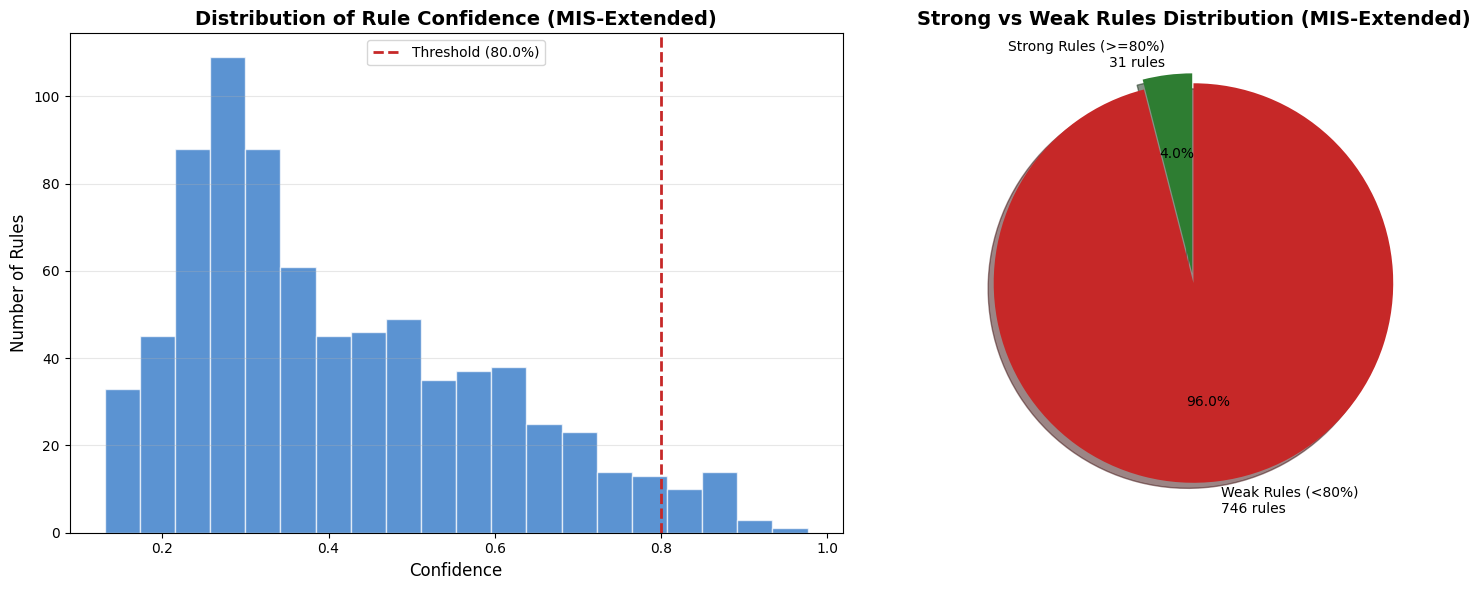

In [32]:
# Identify Strong and Weal Rules (80% Confidence)
mis_strong_rules, mis_weak_rules = mis_apriori.generate_rules()

print("\n" + "=" * 80)
print("MIS-EXTENDED: ASSOCIATION RULES: ")
print("=" * 80)
print(f"\nConfidence Threshold: {MIN_CONFIDENCE * 100}%")
print(f"\nTotal Rules Generated: {len(mis_strong_rules) + len(mis_weak_rules)}")
print(f"  Strong Rules (confidence >= {MIN_CONFIDENCE*100}%): {len(mis_strong_rules)}")
print(f"  Weak Rules (confidence < {MIN_CONFIDENCE*100}%): {len(mis_weak_rules)}")
print("\n" + "=" * 80)

# Display Top 10 Strong association rules 
print("Top 10 Strong Association Rules: ")
print("=" * 80)

print(f"{'Rank':<6} {'Rule':<55} {'Supp':<8} {'Conf':<8} {'Lift':<8}")
print("-" * 80)

for i, rule in enumerate(mis_strong_rules[:10], 1):
    strong_ant_str = ', '.join(list(rule['antecedent']))[:22]
    strong_cons_str = ', '.join(list(rule['consequent']))[:22]
    strong_rule_str = f"{{{strong_ant_str}}} -> {{{strong_cons_str}}}"
    print(f"{i:<6} {strong_rule_str:<55} {rule['support']*100:<7.2f}% {rule['confidence']*100:<7.2f}% {rule['lift']:<7.2f}")

print("\n" + "=" * 80)

# Display Top 10 Weak association rules 
print("Top 10 Weak Association Rules: ")
print("=" * 80)

print(f"{'Rank':<6} {'Rule':<55} {'Supp':<8} {'Conf':<8} {'Lift':<8}")
print("-" * 80)

for i, rule in enumerate(mis_weak_rules[:10], 1):
    strong_ant_str = ', '.join(list(rule['antecedent']))[:22]
    strong_cons_str = ', '.join(list(rule['consequent']))[:22]
    strong_rule_str = f"{{{strong_ant_str}}} -> {{{strong_cons_str}}}"
    print(f"{i:<6} {strong_rule_str:<55} {rule['support']*100:<7.2f}% {rule['confidence']*100:<7.2f}% {rule['lift']:<7.2f}")

print("\n" + "=" * 80)

# Create confidence distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All rules confidence distro
all_confidences = [r['confidence'] for r in mis_strong_rules + mis_weak_rules]

axes[0].hist(all_confidences, bins=20, color='#1565C0', edgecolor='white', alpha=0.7)
axes[0].axvline(x=MIN_CONFIDENCE, color='#C62828', linestyle='--', linewidth='2', label=f'Threshold ({MIN_CONFIDENCE*100}%)')
axes[0].set_xlabel('Confidence', fontsize=12)
axes[0].set_ylabel('Number of Rules', fontsize=12)
axes[0].set_title('Distribution of Rule Confidence (MIS-Extended)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Strong vs weak rules pie chart
sizes = [len(mis_strong_rules), len(mis_weak_rules)]
labels = [f'Strong Rules (>=80%)\n{len(mis_strong_rules)} rules', f'Weak Rules (<80%)\n{len(mis_weak_rules)} rules']
colors = ['#2E7D32', '#C62828']
explode = (0.05, 0)

axes[1].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
axes[1].set_title('Strong vs Weak Rules Distribution (MIS-Extended)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/mis_association_rules_analysis.png', dpi=150, bbox_inches='tight')
plt.show()




In [33]:
# Head Itemset Pruning Analysis
print("\n" + "=" * 80)
print("HEAD ITEMSET PRUNING ANALYSIS (Structural Efficiency)")
print("=" * 80)

total_saved = 0
print(f"{'Level':<10} {'Candidates Saved by Head-Item Rule':<40}")
print("-" * 80)

for k, stats in mis_apriori.level_stats.items():
    if k > 1:
        # This tracks candidates that standard Apriori would have killed 
        # but MIS allowed to survive because the head item was not in the infrequent subset.
        saved = getattr(mis_apriori, 'head_itemset_saved', {}).get(k, 0)
        total_saved += saved
        print(f"Level {k:<5} | {saved:<38}")

print("-" * 80)
print(f"Total patterns saved by MIS-specific pruning: {total_saved}")

# Refined visibility check
print(f"\n{'Item':<45} | {'As Antecedent':<15} | {'As Consequent':<15}")
print("-" * 80)
for item in MIS_THRESHOLDS.keys():
    as_ant = sum(1 for r in mis_strong_rules if item in r['antecedent'])
    as_cons = sum(1 for r in mis_strong_rules if item in r['consequent'])
    print(f"{item[:45]:<45} | {as_ant:<15} | {as_cons:<15}")



HEAD ITEMSET PRUNING ANALYSIS (Structural Efficiency)
Level      Candidates Saved by Head-Item Rule      
--------------------------------------------------------------------------------
Level 2     | 0                                     
Level 3     | 0                                     
Level 4     | 0                                     
--------------------------------------------------------------------------------
Total patterns saved by MIS-specific pruning: 0

Item                                          | As Antecedent   | As Consequent  
--------------------------------------------------------------------------------
WHITE HANGING HEART T-LIGHT HOLDER            | 1               | 0              
REGENCY CAKESTAND 3 TIER                      | 3               | 0              
CHOCOLATE HOT WATER BOTTLE                    | 0               | 7              
RED HANGING HEART T-LIGHT HOLDER              | 0               | 0              
STRAWBERRY CHARLOTTE BAG        

In [34]:
# Evaluate Adaptability for Skewed Distributions

# Analyze item frequency distribution
item_frequencies = list(item_counts.values())

print("\n" + "=" * 80)
print("ITEM FREQUENCY DISTRIBUTION ANALYSIS")
print("=" * 80)

print(f"\nTotal Unique Items: {len(item_frequencies)}")
print(f"Mean Frequency: {np.mean(item_frequencies):.2f}")
print(f"Median Frequency: {np.median(item_frequencies):.2f}")
print(f"Standard Deviation: {np.std(item_frequencies):.2f} ")
print(f"Max Frequency: {max(item_frequencies)}")
print(f"Min Frequency: {min(item_frequencies)}")

# Categorize items by frequency
high_freq = [f for f in item_frequencies if f >= 100]
mid_freq = [f for f in item_frequencies if 50<= f < 100]
low_freq = [f for f in item_frequencies if f < 50]

print(f"\nFrequency Distribution: ")
print(f"  High Frequency (>= 100) {len(high_freq)} items ({len(high_freq)/len(item_frequencies)*100:.1f}%)")
print(f"  Medium Frequency (>= 100) {len(mid_freq)} items ({len(mid_freq)/len(item_frequencies)*100:.1f}%)")
print(f"  Low Frequency (>= 100) {len(low_freq)} items ({len(low_freq)/len(item_frequencies)*100:.1f}%)")





ITEM FREQUENCY DISTRIBUTION ANALYSIS

Total Unique Items: 2788
Mean Frequency: 17.36
Median Frequency: 9.00
Standard Deviation: 22.53 
Max Frequency: 275
Min Frequency: 1

Frequency Distribution: 
  High Frequency (>= 100) 38 items (1.4%)
  Medium Frequency (>= 100) 182 items (6.5%)
  Low Frequency (>= 100) 2568 items (92.1%)


In [35]:
# Comparison, Analysis and Reflection

# Create a class for Standard Apriori
class StandardApriori:
    def __init__(self, min_support=MIN_SUPPORT, min_confidence=MIN_CONFIDENCE, max_k=MAX_K):
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.max_k = max_k
        self.frequent_itemsets = {}
        self.execution_time = 0 
        self.transactions = []
        self.total_transactions = 0
        self.level_stats = {}
        # Tracking computational consumption
        self.consumption_stats = {
            'subset_checks': {},    # (Candidates Scanned * Total Transactions)
            'join_ops': {},         # Number of potential pair comparisons
            'memory_itemsets': {}   # Peak candidates stored in RAM
        }


    def load_data(self, filepath):
        # Load dataset and create transactions
        df = pd.read_csv(filepath)
        self.transactions = []
        for invoice, group in df.groupby('Invoice'):
            items = set(group['Description'].dropna().unique())
            if items:
                self.transactions.append(items)
        self.total_transactions = len(self.transactions)
        return self
    
    def run(self, verbose=False):
        start_time = time.time()
        min_support_count = int(self.min_support * self.total_transactions)

        # Level 1
        item_counts = defaultdict(int)
        for t in self.transactions:
            for item in t:
                item_counts[item] += 1
        
        frequent_1 = {frozenset([item]): count for item, count in item_counts.items() if count >= min_support_count}
        pruned_1 = {frozenset([item]): count for item, count in item_counts.items() if count < min_support_count}

        self.frequent_itemsets.update(frequent_1)
        self.level_stats[1] = {'candidates': len(frequent_1) + len(pruned_1), 'qualified': len(frequent_1), 'pruned': len(pruned_1)}

        # Level 1 Consumption stats
        self.consumption_stats['subset_checks'][1] = len(item_counts) * self.total_transactions
        self.consumption_stats['memory_itemsets'][1] = len(item_counts)

        current_level = frequent_1

        # Level 2 to max_k
        for k in range(2, self.max_k + 1):
            if not current_level:
                break

            # Generate candidates
            candidates = set()
            items = list(current_level.keys())
            join_attempts = 0 # TRACKING START

            for i in range(len(items)):
                for j in range(i + 1, len(items)):
                    join_attempts += 1
                    itemset1 = sorted(list(items[i]))
                    itemset2 = sorted(list(items[j]))
                    if k == 2 or itemset1[:k-2] == itemset2[:k-2]:
                        candidate = items[i].union(items[j])
                        if len(candidate) == k:
                            candidates.add(candidate)
            # Record Join Cost and Peak Memory (Raw candidates)
            self.consumption_stats['join_ops'][k] = join_attempts
            self.consumption_stats['memory_itemsets'][k] = len(candidates)
            candidates_after_join = len(candidates)

            # Prune
            for c in list(candidates):
                subsets = [frozenset(x) for x in itertools.combinations(c, k-1)]
                if not all(s in current_level for s in subsets):
                    candidates.remove(c)
            
            # Count support
            # Record database work for remaining candidates
            total_checks = len(candidates) * self.total_transactions
            self.consumption_stats['subset_checks'][k] = total_checks

            counts = {c: sum(1 for t in self.transactions if c.issubset(t)) for c in candidates}
            frequent_k = {c: v for c, v in counts.items() if v >= min_support_count}
            pruned_k = {c: v for c, v in counts.items() if v < min_support_count}

            self.level_stats[k] = {'candidates': candidates_after_join, 'qualified': (frequent_k), 'pruned': len(pruned_k)}

            if frequent_k:
                self.frequent_itemsets.update(frequent_k)
                current_level = frequent_k
            else:
                current_level = {}
        
        self.execution_time = time.time() - start_time
        return self
    
    def print_consumption_report(self):
        print("\n" + "=" * 80)
        print("COMPUTATIONAL CONSUMPTION SUMMARY (STANDARD APRIORI)")
        print("=" * 80)
        for k in sorted(self.consumption_stats['subset_checks'].keys()):
            checks = self.consumption_stats['subset_checks'][k]
            joins = self.consumption_stats['join_ops'].get(k, 0)
            mem = self.consumption_stats['memory_itemsets'].get(k, 0)
            print(f"Level {k}:")
            print(f"  - Join Cost (Comparisons): {joins:,}")
            print(f"  - Database Scan Cost (Subset Checks): {checks:,}")
            print(f"  - Memory Footprint (Candidates): {mem:,}")

    def generate_rules(self):
        strong_rules, weak_rules = [], []
        for itemset, support in self.frequent_itemsets.items():
            if len(itemset) < 2:
                continue
            for i in range(1, len(itemset)):
                for antecedent in itertools.combinations(itemset, 1):
                    antecedent = frozenset(antecedent)
                    consequent = itemset - antecedent
                    ant_support = self.frequent_itemsets.get(antecedent, 0)
                    if ant_support > 0:
                        confidence = support / ant_support
                        rule = {'antecedent': antecedent, 'consequent': consequent,
                                'support': support / self.total_transactions, 'confidence': confidence}
                        if confidence >= self.min_confidence:
                            strong_rules.append(rule)
                        else:
                            weak_rules.append(rule)

        return strong_rules, weak_rules

# Run standard apriori
std_apriori = StandardApriori(min_support=MIN_SUPPORT, min_confidence=MIN_CONFIDENCE, max_k=MAX_K)
std_apriori.load_data(filepath)
std_apriori.run(verbose=False)
std_apriori.print_consumption_report()
std_strong, std_weak = std_apriori.generate_rules()

print("Standard Apriori executed for comparison")


COMPUTATIONAL CONSUMPTION SUMMARY (STANDARD APRIORI)
Level 1:
  - Join Cost (Comparisons): 0
  - Database Scan Cost (Subset Checks): 5,023,976
  - Memory Footprint (Candidates): 2,788
Level 2:
  - Join Cost (Comparisons): 65,703
  - Database Scan Cost (Subset Checks): 118,396,806
  - Memory Footprint (Candidates): 65,703
Level 3:
  - Join Cost (Comparisons): 43,956
  - Database Scan Cost (Subset Checks): 928,030
  - Memory Footprint (Candidates): 892
Level 4:
  - Join Cost (Comparisons): 496
  - Database Scan Cost (Subset Checks): 5,406
  - Memory Footprint (Candidates): 32
Standard Apriori executed for comparison


In [36]:
# Space Search Analytics

print(f"{'Level':<10} {'Standard':<20} {'MIS-Extended':<20} {'Reduction':<10}")
for k in range(1, 6):
    std = std_apriori.level_stats.get(k, {}).get('candidates', 0)
    mis = mis_apriori.level_stats.get(k, {}).get('candidates', 0)
    red = ((std - mis) / std * 100) if std > 0 else 0
    print(f"Level {k:<4} {std:<20,} {mis:<20,} {red:.1f}%")

Level      Standard             MIS-Extended         Reduction 
Level 1    2,788                2,788                0.0%
Level 2    65,703               65,703               0.0%
Level 3    892                  1,020                -14.3%
Level 4    32                   14                   56.2%
Level 5    0                    0                    0.0%


In [37]:
# Create comparison table
print("\n" + "=" * 80)
print("COMPARISON: Standard Apriori vs MIS-Extended Apriori")
print("=" * 80)

comparison_data = {
    'Metric': [
        'Total Frequent Itemsets',
        'Total Rules Generated',
        'Strong Rules (>=80%)',
        'Weak Rules (<80%)',
        'Execution Time (seconds)',
        'Candidate Reduction'
    ],
    'Standard Apriori': [
        len(std_apriori.frequent_itemsets),
        len(std_strong) + len (std_weak),
        len(std_strong),
        len(std_weak),
        f"{std_apriori.execution_time:.4f}",
        "-"
    ],
    'MIS-Extended': [
        len(mis_apriori.frequent_itemsets),
        len(mis_strong_rules) + len(mis_weak_rules),
        len(mis_strong_rules),
        len(mis_weak_rules),
        f"{mis_apriori.execution_time:.4f}",
        f"{((sum(s['candidates'] for s in std_apriori.level_stats.values()) - sum(s['candidates'] for s in mis_apriori.level_stats.values())) / sum(s['candidates'] for s in std_apriori.level_stats.values()) * 100):.1f}%"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Calculate improvement metrics
itemsets_diff = len(mis_apriori.frequent_itemsets) - len(std_apriori.frequent_itemsets)
strong_diff = len(mis_strong_rules) - len(std_strong)


print(f"\nKey Insights: ")
print(f"  - MIS discovered {itemsets_diff} more frequent itemsets ({itemsets_diff/len(std_apriori.frequent_itemsets)*100:.1f}%)")
print(f"  - MIS generated {strong_diff} more strong rules ({strong_diff/len(mis_strong_rules)*100:.1f}%)")
print(f"  - Time difference {abs(mis_apriori.execution_time - std_apriori.execution_time):.4f}s")



COMPARISON: Standard Apriori vs MIS-Extended Apriori
                  Metric Standard Apriori MIS-Extended
 Total Frequent Itemsets              692          689
   Total Rules Generated              786          777
    Strong Rules (>=80%)               13           31
       Weak Rules (<80%)              773          746
Execution Time (seconds)           4.8362      12.5010
     Candidate Reduction                -        -0.2%

Key Insights: 
  - MIS discovered -3 more frequent itemsets (-0.4%)
  - MIS generated 18 more strong rules (58.1%)
  - Time difference 7.6648s


In [38]:
# Strong vs Weak Rules Summary Table
print("\n" + "=" * 80)
print("STRONG vs WEAK Rules Summary")
print("=" * 80)

rules_summary = {
    'Algorithm': ['Standard Apriori', 'Standard Apriori', 'MIS-Extended', 'MIS_EXTENDED'],
    'Rule Type': ['Strong (>=80%)', 'Weak (<80%)', 'Strong (>=80%)', 'Weak (<80%)'],
    'Count': [len(std_strong), len(std_weak), len(mis_strong_rules), len(mis_weak_rules)],
    'Percentage': [
        f"{len(std_strong)/(len(std_strong)+len(std_weak))*100:.1f}%",
        f"{len(std_weak)/(len(std_strong)+len(std_weak))*100:.1f}%",
        f"{len(mis_strong_rules)/(len(mis_strong_rules)+len(mis_weak_rules))*100:.1f}%",
        f"{len(mis_weak_rules)/(len(mis_strong_rules)+len(mis_weak_rules))*100:.1f}%"
    ]
}

rules_df = pd.DataFrame(rules_summary)
print(rules_df.to_string(index=False))


STRONG vs WEAK Rules Summary
       Algorithm      Rule Type  Count Percentage
Standard Apriori Strong (>=80%)     13       1.7%
Standard Apriori    Weak (<80%)    773      98.3%
    MIS-Extended Strong (>=80%)     31       4.0%
    MIS_EXTENDED    Weak (<80%)    746      96.0%


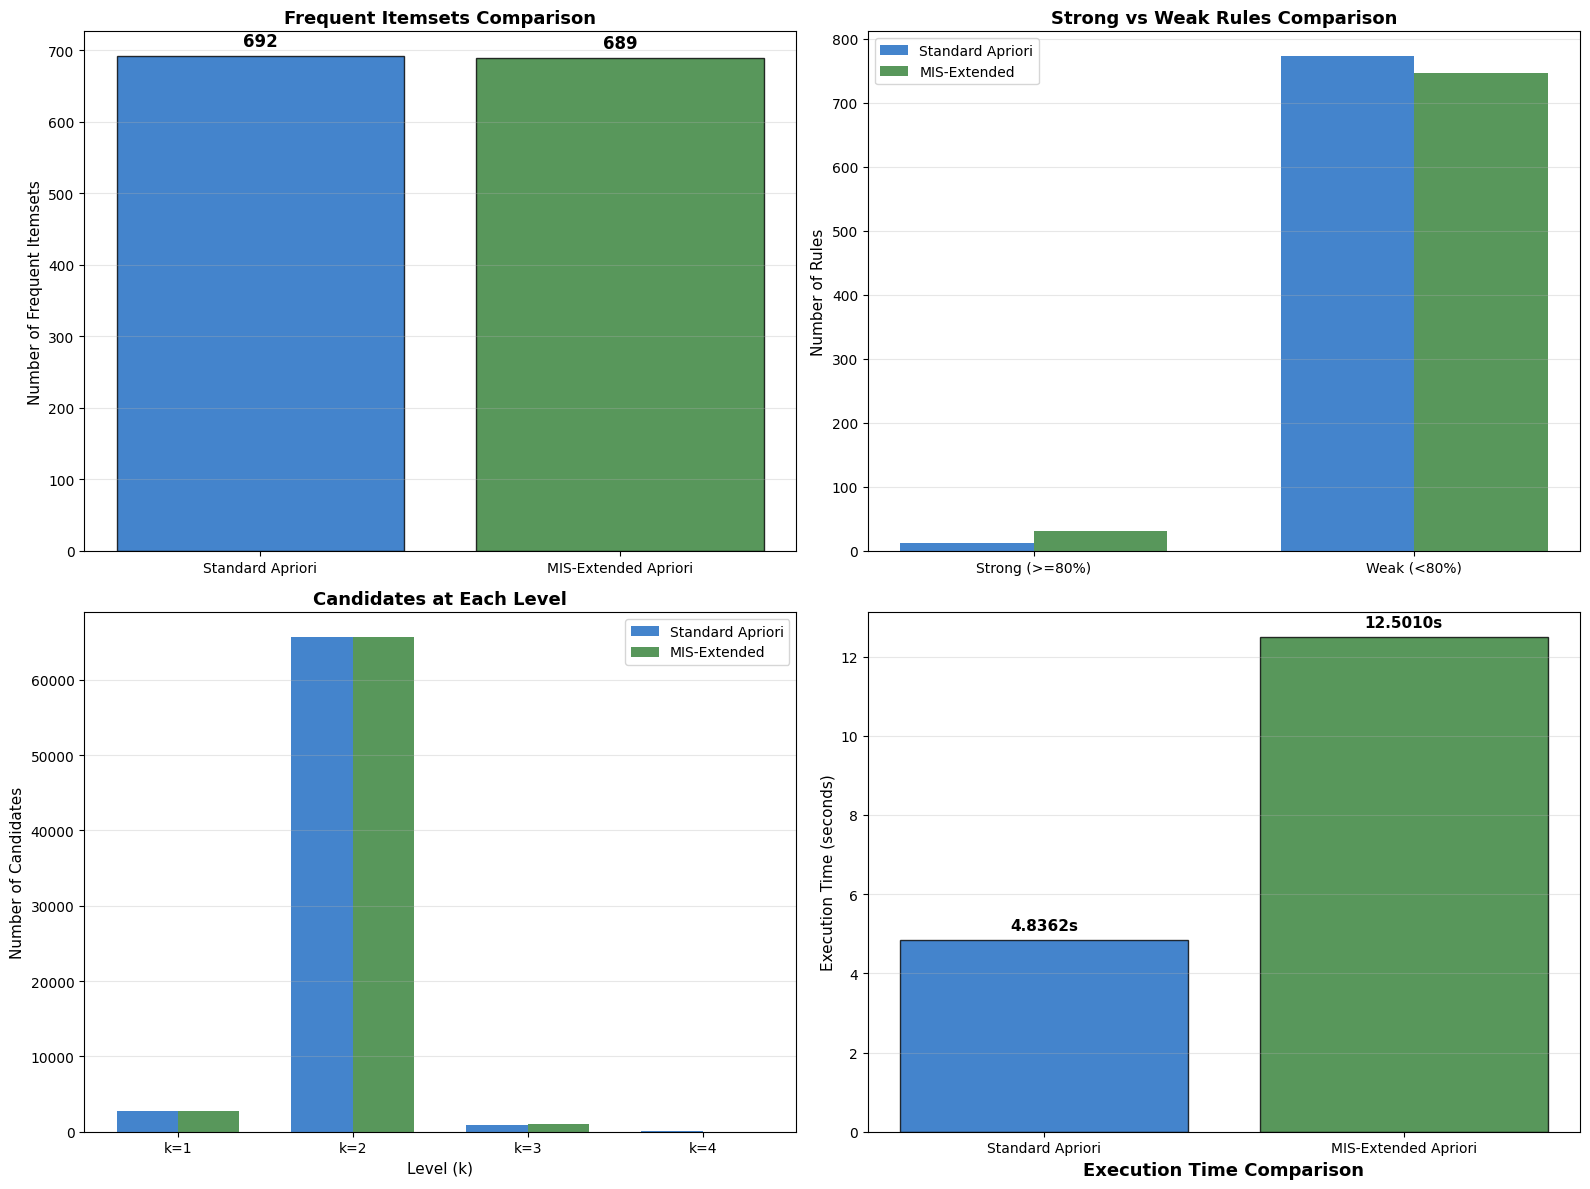

In [42]:
# Visualizations: MIS vs Standard Apriori Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Frequent Itemsets Comparison
algorithms = ['Standard Apriori', 'MIS-Extended Apriori']
itemsets = [len(std_apriori.frequent_itemsets), len(mis_apriori.frequent_itemsets)]
colors = ['#1565C0', '#2E7D32']

axes[0, 0].bar(algorithms, itemsets, color=colors, alpha=0.8, edgecolor='black')
axes[0, 0].set_ylabel('Number of Frequent Itemsets', fontsize=11)
axes[0, 0].set_title('Frequent Itemsets Comparison', fontsize=13, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(itemsets):
    axes[0, 0].text(i, v + max(itemsets)*0.02, str(v), ha='center', fontsize=12, fontweight='bold')

# Rules Comparison
x = np.arange(2)
width = 0.35
std_rules = [len(std_strong), len(std_weak)]
mis_rules = [len(mis_strong_rules), len(mis_weak_rules)]

axes[0, 1].bar(x - width/2, std_rules, width, label='Standard Apriori', color="#1565C0", alpha=0.8)
axes[0, 1].bar(x + width/2, mis_rules, width, label='MIS-Extended', color="#2E7D32", alpha=0.8)
axes[0, 1].set_ylabel('Number of Rules', fontsize=11)
axes[0, 1].set_title('Strong vs Weak Rules Comparison', fontsize=13, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(['Strong (>=80%)', 'Weak (<80%)'])
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Level-wise Candidate Comparison
std_levels = list(std_apriori.level_stats.keys())
std_candidates = [std_apriori.level_stats[l]['candidates'] for l in std_levels]
mis_candidates = [mis_apriori.level_stats[l]['candidates'] for l in std_levels]

x = np.arange(len(std_levels))
axes[1, 0].bar(x - width/2, std_candidates, width, label='Standard Apriori', color="#1566C0", alpha=0.8)
axes[1, 0].bar(x + width/2, mis_candidates, width, label='MIS-Extended', color="#2E7D32", alpha=0.8)
axes[1, 0].set_xlabel('Level (k)', fontsize=11)
axes[1, 0].set_ylabel('Number of Candidates', fontsize=11)
axes[1, 0].set_title('Candidates at Each Level', fontsize=13, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels([f'k={l}' for l in std_levels])
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Excution Time Comparison
times = [std_apriori.execution_time, mis_apriori.execution_time]
axes[1, 1].bar(algorithms, times, color=colors, alpha=0.8, edgecolor='black')
axes[1, 1].set_ylabel('Execution Time (seconds)', fontsize=11)
axes[1, 1].set_xlabel('Execution Time Comparison', fontsize=13, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(times):
    axes[1, 1].text(i, v + max(times)*0.02, f'{v:.4f}s', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/mis_vs_standard_comparison.png', dpi=150, bbox_inches='tight')

plt.show()



C:\Users\admin\AppData\Local\Temp\ipykernel_22908\3450328844.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=[f'Level {k}' for k in sorted_levels], patch_artist=True)


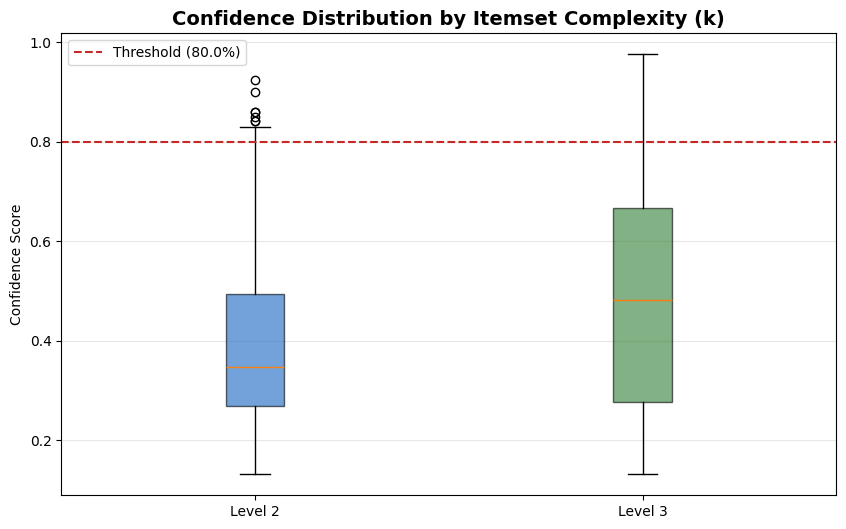

In [41]:
# Visulaize confidence distribution at each level

# 1. Group rules by k-level
rules_by_level = {}
for rule in mis_strong_rules + mis_weak_rules:
    k = len(rule['antecedent']) + len(rule['consequent'])
    if k not in rules_by_level:
        rules_by_level[k] = []
    rules_by_level[k].append(rule['confidence'])

# 2. Sort levels for plotting
sorted_levels = sorted(rules_by_level.keys())
if sorted_levels:
    plt.figure(figsize=(10, 6))
    data_to_plot = [rules_by_level[k] for k in sorted_levels]
    
    # Create the boxplot
    bp = plt.boxplot(data_to_plot, labels=[f'Level {k}' for k in sorted_levels], patch_artist=True)
    
    # Styling
    colors = ['#1565C0', '#2E7D32', '#EF6C00', '#6A1B9A']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    plt.axhline(y=MIN_CONFIDENCE, color='#C62828', linestyle='--', label=f'Threshold ({MIN_CONFIDENCE*100}%)')
    plt.title('Confidence Distribution by Itemset Complexity (k)', fontsize=14, fontweight='bold')
    plt.ylabel('Confidence Score')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    
    plt.savefig('../visuals/mis_confidence_by_level_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()